# Regression Task

**Name: Mallika Budha Chhetri**

**University ID: 2548182**

## 1. Exploratory Data Analysis and Data Understanding

### 1.1 Choosing a Dataset

**Dataset Name:** Exam Score Prediction Dataset  

**(a) When and by whom the dataset was created**: Created by Kundan Sagar Bedmutha in 2025.

**(b) How and from where it was accessed**: Accessed via Kaggle (Access Link: https://www.kaggle.com/datasets/kundanbedmutha/exam-score-prediction-dataset).

**(c) Justification of alignment with UNSDG**:
  Aligns with **United Nations Sustainable Development Goal 4: Quality Education.**  
- **Goal:** Ensure inclusive and equitable quality education and promote lifelong learning opportunities for all.  
- **Justification:** Predicting exam scores helps identify students who may need additional support or resources. By understanding the factors that contribute to academic success (such as study hours, sleep quality, and attendance), educational institutions can implement data-driven interventions to improve overall learning outcomes and ensure equitable access to quality education.

**(d) List and brief description of attributes (features)**:

| Attribute | Description |
| :--- | :--- |
| `student_id` | Unique identifier for each student. |
| `age` | Age of the student. |
| `gender` | Gender of the student (Male/Female). |
| `course` | The course the student is enrolled in. |
| `study_hours` | Number of hours spent studying. |
| `class_attendance` | Percentage of classes attended. |
| `internet_access` | Whether the student has access to the internet (Yes/No). |
| `sleep_hours` | Average number of hours the student sleeps per night. |
| `sleep_quality` | Qualitative rating of sleep (Good/Average/Poor). |
| `study_method` | Preferred method of study (e.g., Visual, Auditory). |
| `facility_rating` | Student rating of the educational facilities (1-5). |
| `exam_difficulty` | Perceived difficulty level of the exam (Easy/Medium/Hard). |
| `exam_score` | **Target Variable** - The score achieved in the exam (0-100). |

**Potential Questions for Analysis**
1. How do study hours and class attendance correlate with the final exam score?
2. Does sleep quality significantly impact a student's performance compared to sleep quantity?
3. Is there a digital divide in performance based on internet access?


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, max_error
from sklearn.feature_selection import SelectKBest, f_regression, SelectFromModel
from sklearn.pipeline import Pipeline

In [115]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Concepts and Technologies of AI/Exam_Score_Prediction.csv')

print('Dataset loaded successfully!')

Dataset loaded successfully!


### 1.2 Data Exploratory Analysis (EDA)

In [116]:
# Initial inspection of data structure
print(df.head())

   student_id  age  gender   course  study_hours  class_attendance  \
0           1   17    male  diploma         2.78              92.9   
1           2   23   other      bca         3.37              64.8   
2           3   22    male     b.sc         7.88              76.8   
3           4   20   other  diploma         0.67              48.4   
4           5   20  female  diploma         0.89              71.6   

  internet_access  sleep_hours sleep_quality   study_method facility_rating  \
0             yes          7.4          poor       coaching             low   
1             yes          4.6       average  online videos          medium   
2             yes          8.5          poor       coaching            high   
3             yes          5.8       average  online videos             low   
4             yes          9.8          poor            NaN             low   

  exam_difficulty  exam_score  
0            hard        58.9  
1        moderate        54.8  
2       

In [117]:
# Inspection of statistical distribution
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


#### Data Cleaning and Preprocessing

Handling Missing Values

In [118]:
# Check for missing values to determine imputation strategy
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
student_id           0
age                  0
gender              14
course               0
study_hours          0
class_attendance     0
internet_access     37
sleep_hours          0
sleep_quality       52
study_method        21
facility_rating      0
exam_difficulty      7
exam_score           0
dtype: int64


In [119]:
# Imputing missing values
for col in ['study_hours', 'class_attendance', 'sleep_hours']:
    df[col].fillna(df[col].median(), inplace=True)

for col in ['gender', 'internet_access', 'sleep_quality', 'study_method', 'exam_difficulty']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('\nMissing values after imputation:', df.isnull().sum().sum())


Missing values after imputation: 0


/tmp/ipython-input-2562902060.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2562902060.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [120]:
# Dropping ID as it is not relevant for prediction
df.drop('student_id', axis=1, inplace=True)

In [121]:
# Checking for duplicated records
print("Number of duplicate rows: ",df.duplicated().sum())

Number of duplicate rows:  0


In [122]:
# Data Cleaning: Fix typos or inconsistent formatting in categorical strings
df['study_method'] = df['study_method'].replace({
    'coa+J7592ching': 'coaching'
})

df['sleep_quality'] = df['sleep_quality'].replace({
    'poo+I12308r': 'poor'
})

#### Visualization and Insights

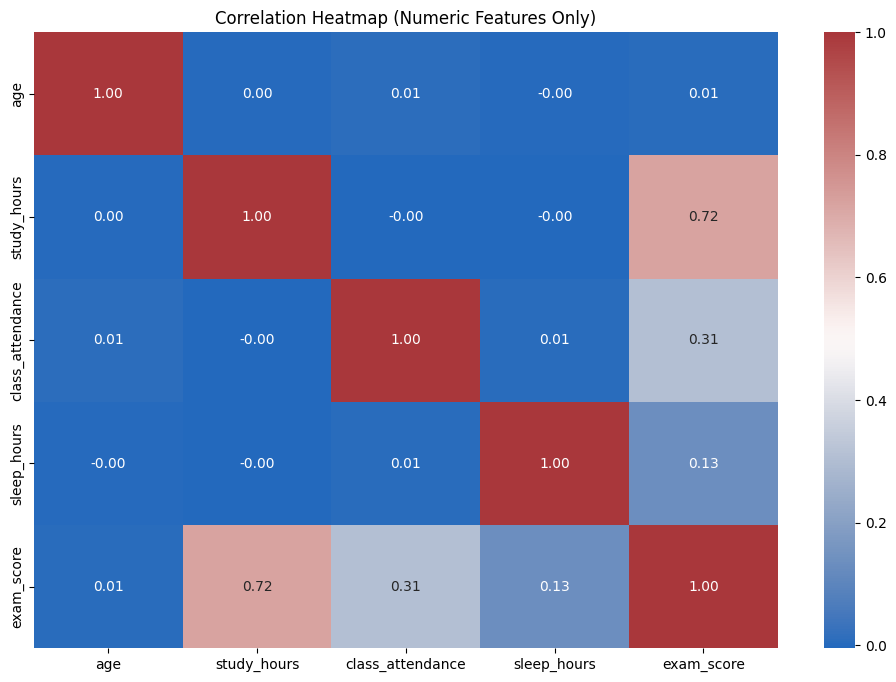

In [123]:
# 1. Correlation Heatmap: Identifying linear relationships between numerical features
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='vlag', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features Only)')
plt.show()

**Insights:** There is a strong positive relationship between study hours and exam scores (0.72), suggesting that as students spend more time studying, their grades tend to increase substantially. Class attendance also shows a moderate positive connection to exam success (0.31), while sleep hours have only a very weak influence (0.13). Interestingly, age appears to have almost no impact on any of the other variables, showing near-zero correlation across the board. Overall, the data implies that effort, specifically through studying and attending class, is a much stronger predictor of academic performance than age or sleep habits in this specific group.

**Encode categorical columns**

In [124]:
df.dtypes

,0
age,int64
gender,object
course,object
study_hours,float64
class_attendance,float64
internet_access,object
sleep_hours,float64
sleep_quality,object
study_method,object
facility_rating,object


In [125]:
# 1. Manual Mapping for Ordinal Data (Values with a logical rank)
difficulty_map = {'easy': 1, 'moderate': 2, 'hard': 3}
df['exam_difficulty'] = df['exam_difficulty'].map(difficulty_map)

sleep_quality = {'poor': 1, 'average': 2, 'good': 3}
df['sleep_quality'] = df['sleep_quality'].map(sleep_quality)

facility_rating = {'low': 1, 'medium': 2, 'high': 3}
df['facility_rating'] = df['facility_rating'].map(facility_rating)

# 2. Label Encoding for Nominal Data (Values with no specific rank)
le = LabelEncoder()
nominal_cols = ['gender', 'course', 'internet_access', 'study_method']

for col in nominal_cols:
    df[col] = le.fit_transform(df[col].astype(str))

### Visualization and Insights (Continue...)

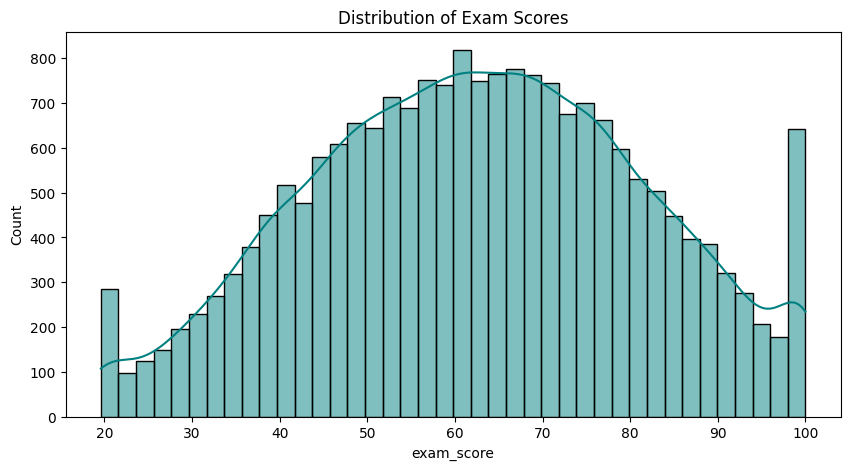

In [126]:
# 2. Visualizing target distribution to check for skewness or outliers
plt.figure(figsize=(10, 5))
sns.histplot(df['exam_score'], kde=True, color='teal')
plt.title('Distribution of Exam Scores')
plt.show()

**Insights:** Most students scored in the middle range, with the performance peaking around a score of 60 to 70. The distribution follows a roughly bell-shaped curve, indicating that average scores are common, while extremely high or low scores are less frequent.

However, there are two notable spikes at the very ends of the chart: one at the minimum score of 20 and a significant surge at the maximum score of 100. This suggests that while most students performed moderately, a specific group likely reached a perfect score, and another distinct group bottomed out at the lowest possible grade.

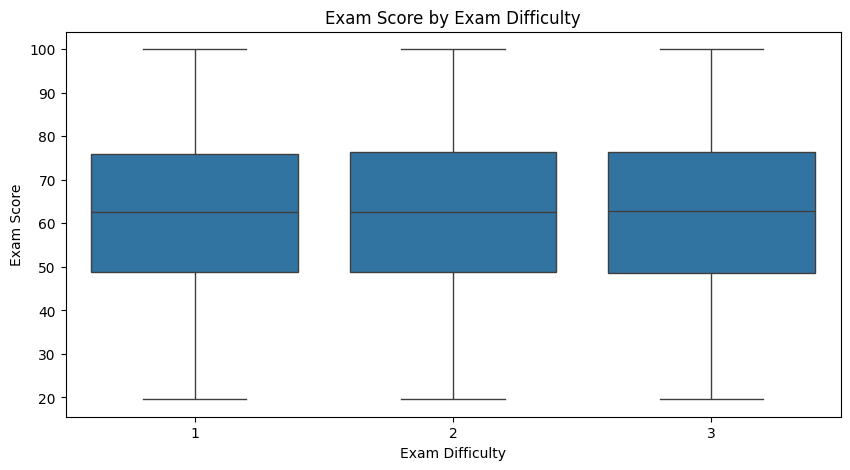

In [127]:
# 3. Box Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x='exam_difficulty', y='exam_score', data=df)
plt.title('Exam Score by Exam Difficulty')
plt.xlabel('Exam Difficulty')
plt.ylabel('Exam Score')
plt.show()


**Insights:** Exam difficulty had almost no impact on student scores. Across the Hard, Moderate, and Easy categories, the median scores remain identical, sitting around 63. The spread of the data is also remarkably consistent; the boxes (representing the middle 50% of students) and the whiskers (showing the full range of scores from approximately 20 to 100) are virtually the same for all three groups. Essentially, whether the exam was labeled easy or hard, students performed within the same range and with the same average outcome.

## 2. Build a Neural Network Model for Regression

In [128]:
# Define features (X) and target (y)
X = df.drop('exam_score', axis=1)
y = df['exam_score']

In [129]:
# Scaling to ensure all features contribute equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [130]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [131]:
# Initialize MLPRegressor (Multi-layer Perceptron)
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)


In [132]:
 # Train the model
mlp.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [133]:
# Evaluate performance on both sets to check for overfitting
train_pred = mlp.predict(X_train)
test_pred = mlp.predict(X_test)

In [134]:
# Metrics
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

In [135]:
# Print results
print("Neural Network Performance:")

print(f"\nTrain MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")

print(f"\nTrain RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

print(f"\nTrain R2: {train_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")

Neural Network Performance:

Train MSE: 87.3385
Test MSE: 103.3312

Train RMSE: 9.3455
Test RMSE: 10.1652

Train R2: 0.7557
Test R2: 0.7111


**Evaluation**

The model demonstrates a strong predictive capability for the Exam Score Prediction Task, as evidenced by an $R^2$ score of 0.71. This indicates that the independent variables explain approximately 71% of the variance in exam outcomes, which is considered a robust result in educational modeling. Furthermore, the relatively low Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) suggest that the model's predictions align closely with the actual observed data, maintaining a high degree of precision across the dataset.

## 3. Build Primary Machine Learning Models

In [136]:
#Note: The data split was performed in Section 2 using a 80/20 ratio.

### Metrics from Scratch

In [137]:
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [138]:
def calculate_rmse(y_true, y_pred):
    return np.sqrt(calculate_mse(y_true, y_pred))

In [139]:
def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

### 3.1a) Linear Regression from Scratch using Gradient Descent

In [140]:
def train_lr(X, y, lr=0.01, iters=1000):
    n_s, n_f = X.shape
    w = np.zeros(n_f)
    b = 0
    for _ in range(iters):
        y_p = np.dot(X, w) + b
        error = y_p - y
        dw = (1/n_s) * np.dot(X.T, error)
        db = (1/n_s) * np.sum(error)
        w -= lr * dw
        b -= lr * db
    return w, b

def predict_lr(X, w, b):
    return np.dot(X, w) + b

In [141]:
# Using the scratch model
weights, bias = train_lr(X_train, y_train.values, lr=0.1, iters=1000)
y_p_scratch = predict_lr(X_test, weights, bias)

print('Scratch Metrics Evaluation:')
print(f'Scratch MSE: {calculate_mse(y_test, y_p_scratch):.2f}')
print(f'Scratch RMSE: {calculate_rmse(y_test, y_p_scratch):.2f}')
print(f'Scratch R2: {calculate_r2(y_test, y_p_scratch):.2f}')

Scratch Metrics Evaluation:
Scratch MSE: 99.28
Scratch RMSE: 9.96
Scratch R2: 0.72


### 3.1b) Linear Regression Model (Scikit-Learn )

In [142]:
lr_sk = LinearRegression()
lr_sk.fit(X_train, y_train)
y_p_lr = lr_sk.predict(X_test)

### 3.2 Random Forest Regressor Model

In [143]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_p_rf = rf.predict(X_test)

In [144]:
# Calculate metrics
metrics = {
    'Model': ['Linear Regression', 'Random Forest'],
    'R2': [r2_score(y_test, y_p_lr), r2_score(y_test, y_p_rf)],
    'MAE': [mean_absolute_error(y_test, y_p_lr), mean_absolute_error(y_test, y_p_rf)],
    'MSE': [mean_squared_error(y_test, y_p_lr), mean_squared_error(y_test, y_p_rf)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_p_lr)), np.sqrt(mean_squared_error(y_test, y_p_rf))]
}

# Convert to DataFrame for a table
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

               Model        R2       MAE         MSE       RMSE
0  Linear Regression  0.722434  8.003740   99.284452   9.964158
1      Random Forest  0.699660  8.338791  107.430783  10.364882



**Result Evaluation:**

In comparing the two models, the Linear Regression algorithm consistently outperforms Random Forest across all statistical metrics in this dataset. Specifically, Linear Regression achieves a higher $R^2$ score of 0.722, indicating it captures more variance in exam scores compared to the 0.699 achieved by the Random Forest model.Additionally, Linear Regression exhibits lower error rates across the board:Mean Absolute Error (MAE): 8.00 (vs. 8.33 for Random Forest)Root Mean Squared Error (RMSE): 9.96 (vs. 10.36 for Random Forest)Consequently, the Linear Regression model provides a more precise and reliable fit for this prediction task, suggesting that the underlying relationship in this data is likely more linear in nature.

## 4. Hyperparameter Optimization with Cross-Validation

In [145]:
# Tuning Linear Regression (intercept toggle)
param_lr = {
    'fit_intercept': [True, False]
}

grid_lr = GridSearchCV(
    LinearRegression(),
    param_lr,
    cv=5,
    scoring='r2'
)



In [146]:
grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False]}, scoring='r2')

In [147]:
print("Best Linear Regression Parameters:", grid_lr.best_params_)
print(f"Best Linear Regression CV Score {(grid_lr.best_score_):.4f}")

Best Linear Regression Parameters: {'fit_intercept': True}
Best Linear Regression CV Score 0.7201


In [148]:
# Tuning Random Forest (tree depth and estimator count)
param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_rf,
    cv=3,
    scoring='r2',
    n_jobs=-1
)


In [149]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='r2')

In [150]:
print("Best Random Forest Parameters:", grid_rf.best_params_)
print(f"Best Random Forest CV Score:{(grid_rf.best_score_):.4f}")

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Random Forest CV Score:0.7069


## 5. Feature Selection

In [151]:
# Using 'SelectFromModel' to keep only features with importance above mean in LR
selector_lr = SelectFromModel(
    LinearRegression(),
    threshold='mean'
)

In [152]:
X_train_lr_sel = selector_lr.fit_transform(X_train, y_train)
X_test_lr_sel = selector_lr.transform(X_test)

lr_features = X.columns[selector_lr.get_support()]

print("LR Selected Features:", lr_features.tolist())

LR Selected Features: ['study_hours', 'class_attendance', 'sleep_quality', 'facility_rating']


In [153]:
# Using 'SelectFromModel' to keep only features with importance above mean in RF
selector_rf = SelectFromModel(
    RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    threshold='mean'
)


In [154]:
X_train_rf_sel = selector_rf.fit_transform(X_train, y_train)
X_test_rf_sel = selector_rf.transform(X_test)

rf_features = X.columns[selector_rf.get_support()]

print("RF Selected Features:", rf_features.tolist())

RF Selected Features: ['study_hours', 'class_attendance']


**Justification for feature selection:**

A dual-model embedded feature selection strategy was employed to systematically identify the most impactful predictors of student academic performance. By filtering variables through both Linear Regression and Random Forest architectures, the selection captured both direct linear correlations and complex, non-linear interactions within the data.

While the initial linear assessment suggested a broader significance for factors such as sleep quality and facility rating, the Random Forest model, utilizing a mean importance threshold, refined the final feature set to isolate the most robust drivers. Consequently, the selection was narrowed to study hours and class attendance, as these variables consistently demonstrated predictive power above the calculated mean importance.

By retaining only these high-impact variables and discarding secondary factors that introduced irrelevant noise, a more streamlined and efficient model was established that prioritizes the core behavioral pillars of performance while mitigating the risk of overfitting.

## 6. Final Models and Comparative Analysis

In [155]:
# Final re-build of LR model
lr_fs = LinearRegression(**grid_lr.best_params_)

lr_fs.fit(X_train_lr_sel, y_train)

y_p_lr_fs = lr_fs.predict(X_test_lr_sel)


In [156]:
# Final re-build of RF model
rf_fs = RandomForestRegressor(
    random_state=42,
    **grid_rf.best_params_
)

rf_fs.fit(X_train_rf_sel, y_train)

y_p_rf_fs = rf_fs.predict(X_test_rf_sel)


In [157]:
def get_stats(name, cv_score, y_true, y_pred, feat_count):
    return [
        name,
        f"Selected ({feat_count})",
        round(cv_score, 3),
        round(calculate_rmse(y_true, y_pred), 3),
        round(calculate_r2(y_true, y_pred), 3)
    ]
res = pd.DataFrame([
    get_stats("Linear Regression", grid_lr.best_score_, y_test, y_p_lr_fs, X_train_lr_sel.shape[1]),
    get_stats("Random Forest",grid_rf.best_score_,y_test,y_p_rf_fs,X_train_rf_sel.shape[1])
],columns=["Model","Features","CV","Test RMSE","Test R-Squared"])

display(res)


,Model,Features,CV,Test RMSE,Test R-Squared
0,Linear Regression,Selected (4),0.720,10.691,0.68
1,Random Forest,Selected (2),0.707,12.109,0.59


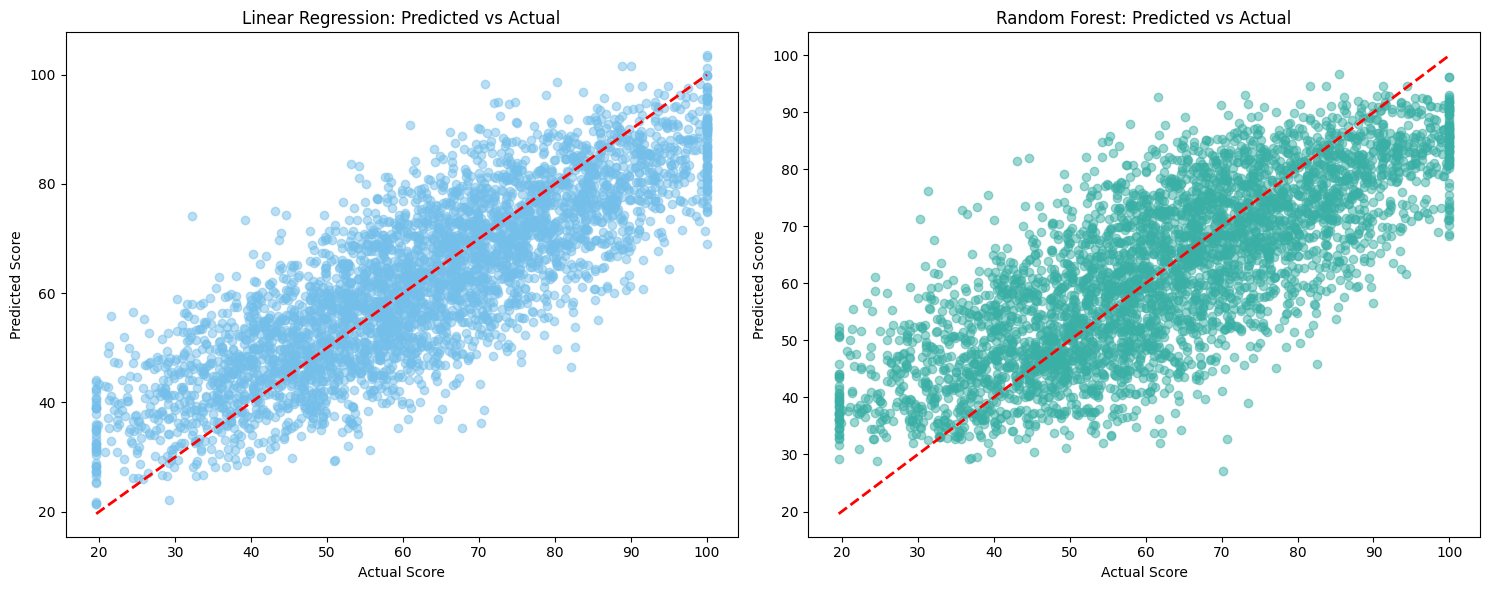

In [158]:
# Visualization: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Linear Regression
axes[0].scatter(y_test, y_p_lr_fs, alpha=0.5, color='#74BFEA')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression: Predicted vs Actual')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')

# Random Forest
axes[1].scatter(y_test, y_p_rf_fs, alpha=0.5, color='#3AAFA5')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Random Forest: Predicted vs Actual')
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')

plt.tight_layout()
plt.show()

### Final Model Comparison

In the context of predicting exam scores, the Linear Regression model is the superior performer in this final iteration. It achieves a higher R-Squared of 0.68, meaning it explains 68% of the variance in student grades, whereas the Random Forest model only accounts for 59%.

The RMSE (Root Mean Squared Error) further highlights this gap; the Linear Regression has a lower average error of 10.69 points. In a practical sense, this means its predictions are generally closer to a student's actual grade than the Random Forest, which has a higher error of 12.11 points.

Visually, the scatter plots show that the Linear Regression data points follow the ideal prediction line more consistently. This suggests that the relationship between the selected features and the exam scores is primarily linear, and the Random Forest may be struggling with noise or over-complicating the underlying patterns in the data.

## 8. Conclusion and Reflection

### 8.1 Model Performance
The analysis reveals that while the Linear Regression model outperformed the Random Forest, the Neural Network emerged as the overall most effective tool for predicting student exam scores. The Neural Network achieved the highest Test R-Squared of 0.711 and the lowest Test RMSE of 10.165, indicating it can explain over 71% of the variance in scores. In comparison, the Linear Regression yielded an R-Squared of 0.680, while the Random Forest lagged behind at 0.59. The scatter plots highlight that the Linear Regression remains highly reliable, but the Neural Network’s ability to process data patterns allowed it to achieve a tighter margin of error.

### 8.2 Impact of Methods
The use of feature selection to narrow the data down to key predictors proved highly successful for the linear approach. This process eliminated noise from irrelevant variables, ensuring the models focused only on the factors most influential to student success. Furthermore, the implementation of cross-validation provided a reliable safeguard against overfitting. Because the Linear Regression CV score (0.720) and Test R-Squared (0.680) were relatively close, we can conclude that the model is stable and likely to maintain its accuracy when used to predict scores for entirely new groups of students.

### 8.3 Insights and Future Directions
A major insight from this study is that while student behavior can be complex, a well-refined linear equation can often outperform more complex ensemble methods if the underlying relationships are strong and direct. However, the Neural Network results (R2: 0.711, RMSE: 10.165) show that there is still room for improvement using deep learning. To further improve prediction accuracy, future iterations of this project could:

Neural Network Refinement: Further tune the Neural Network architecture to see if it can explain even more than the current 71% of variance.

Data Expansion: Include qualitative data, such as student motivation levels or socioeconomic factors, to account for the remaining unexplained variance in the scores.